In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels
!pip install imbalanced-learn

Размер данных: (303, 14)

Пропущенные значения:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

ROC-AUC на тестовой выборке: 0.8837


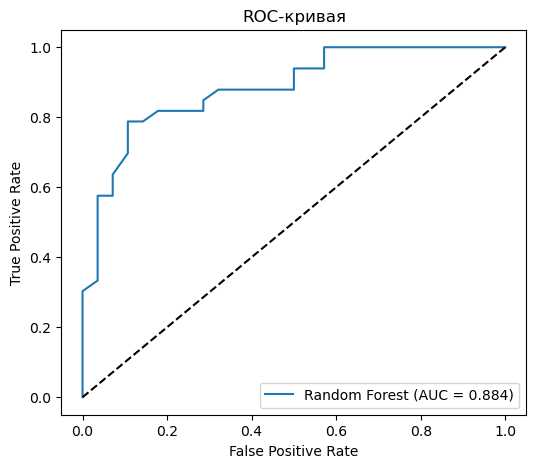

['heart_model.pkl']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('heart.csv')


print("Размер данных:", df.shape)
print("\nПропущенные значения:\n", df.isnull().sum())


X = df.drop('target', axis=1)
y = df['target']


numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_cols = ['sex', 'fbs', 'exang']        
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']


feature_cols = numerical_cols + binary_cols + categorical_cols
X = X[feature_cols]


preprocessor = ColumnTransformer(
    transformers=[
        ('num_bin', 'passthrough', numerical_cols + binary_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', rf)])


pipeline.fit(X_train, y_train)


y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC на тестовой выборке: {roc_auc:.4f}")


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()


train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.show()

import joblib
joblib.dump(pipeline, "heart_model.pkl")